# Capa Silver — Clustering de Urbanización (CDMX)


**Objetivo del pipeline:** construir, a partir de la capa Bronze (ITER, DENUE x9, Marco Geoestadístico, AGEB, Manzanas),
una tabla Gold a **nivel manzana** con las 4 variables del estudio, lista para K-Means, clustering jerárquico y DBSCAN.

| Variable | Definición | Fuente bronze |
|---|---|---|
| `densidad_urbana` | pob_total (municipio) / superficie_total_km2 (municipio) — densidad bruta, asignada como atributo contextual a cada manzana | `bronze_ITER`, `bronze_marco_geoestadistico` |
| `densidad_urbana_neta` | pob_total (municipio) / superficie_urbana_km2 (mancha urbana real, unión de manzanas) | `bronze_ITER`, `bronze_manzanas` |
| `indice_entropia_negocios` | Entropía de Shannon-Wiener sobre 4 categorías SCIAN (Comercio, Servicios, Industria, Otros), por manzana | `bronze_bancos`, `bronze_comida`, `bronze_corporativos`, `bronze_deportes`, `bronze_negocios`, `bronze_negocios_tiendas`, `bronze_restaurantes`, `bronze_tiendas`, `bronze_transporte` |
| `personas_mayores_o_iguales_18` | Suma de `P_18YMAS` por manzana | `bronze_ITER` |

**Nota metodológica:** `densidad_urbana` y `densidad_urbana_neta` se calculan a nivel **municipal**
(porque `superficie_total_km2` y `superficie_urbana_km2` son magnitudes de área que solo tienen sentido agregadas
geográficamente) y luego se **propagan a cada manzana** como atributo contextual (todas las manzanas de un mismo
municipio comparten el mismo valor de estas dos variables). Lo que aporta variación intra-municipal real es la
combinación con `personas_mayores_o_iguales_18` e `indice_entropia_negocios`, que sí se calculan por manzana.
Esto es una práctica común en geografía urbana cuantitativa (atributos de contexto + atributos locales combinados
en clustering), pero conviene declararlo explícitamente en la sección de metodología del artículo.

# CAPA SILVER

En Silver limpiamos, tipamos correctamente, estandarizamos claves geográficas (`CVEGEO`/`CVE_MUN`) y dejamosuna tabla por fuente, ya curada y con tipos correctos — sin agregaciones todavía. Estas tablas son la baseauditable para construir Gold.

## 1. Silver ITER — Demografía por manzana.

`bronze_ITER` trae columnas demográficas tipadas como **string** (incluyendo `POBTOT` y `P_18YMAS`), y usa elcampo `*9*` (valor convencional de INEGI) para "información reservada por confidencialidad estadística" enmanzanas con muy poca población. Hay que castear a numérico y tratar esos casos como nulos, no como ceros.

In [0]:
# Silver: ITER -> demografía limpia a nivel manzana

from pyspark.sql import functions as F
from pyspark.sql.types import LongType

df_iter_bronze = spark.table("bronze_ITER")

# Construir CVEGEO de manzana (Entidad+Municipio+Localidad+AGEB+Manzana) si no viene ya armada.
# Ajusta los nombres de columna si tu CSV trae CVEGEO ya construido.
cols_iter = df_iter_bronze.columns
print(cols_iter)  # <- revisa aquí si existe CVEGEO, MZA, AGEB, etc. Ajusta el bloque siguiente según lo que veas.

['ENTIDAD', 'NOM_ENT', 'MUN', 'NOM_MUN', 'LOC', 'NOM_LOC', 'LONGITUD', 'LATITUD', 'ALTITUD', 'POBTOT', 'POBFEM', 'POBMAS', 'P_0A2', 'P_0A2_F', 'P_0A2_M', 'P_3YMAS', 'P_3YMAS_F', 'P_3YMAS_M', 'P_5YMAS', 'P_5YMAS_F', 'P_5YMAS_M', 'P_12YMAS', 'P_12YMAS_F', 'P_12YMAS_M', 'P_15YMAS', 'P_15YMAS_F', 'P_15YMAS_M', 'P_18YMAS', 'P_18YMAS_F', 'P_18YMAS_M', 'P_3A5', 'P_3A5_F', 'P_3A5_M', 'P_6A11', 'P_6A11_F', 'P_6A11_M', 'P_8A14', 'P_8A14_F', 'P_8A14_M', 'P_12A14', 'P_12A14_F', 'P_12A14_M', 'P_15A17', 'P_15A17_F', 'P_15A17_M', 'P_18A24', 'P_18A24_F', 'P_18A24_M', 'P_15A49_F', 'P_60YMAS', 'P_60YMAS_F', 'P_60YMAS_M', 'REL_H_M', 'POB0_14', 'POB15_64', 'POB65_MAS', 'P_0A4', 'P_0A4_F', 'P_0A4_M', 'P_5A9', 'P_5A9_F', 'P_5A9_M', 'P_10A14', 'P_10A14_F', 'P_10A14_M', 'P_15A19', 'P_15A19_F', 'P_15A19_M', 'P_20A24', 'P_20A24_F', 'P_20A24_M', 'P_25A29', 'P_25A29_F', 'P_25A29_M', 'P_30A34', 'P_30A34_F', 'P_30A34_M', 'P_35A39', 'P_35A39_F', 'P_35A39_M', 'P_40A44', 'P_40A44_F', 'P_40A44_M', 'P_45A49', 'P_45A49_F

In [0]:
# Cada municipio trae una fila LOC=0 ("Total del Municipio") que es la suma de sus localidades reales (LOC>=1).
# Filtramos LOC!=0 y sumamos las localidades reales nosotros mismos, en vez de confiar en el total ya agregado.

# INEGI marca confidencialidad estadística con '*' en estos campos -> tratar como NULL, no como 0
def clean_numeric(col):
    return F.when(F.col(col).rlike("^[0-9]+$"), F.col(col).cast(LongType())).otherwise(F.lit(None).cast(LongType()))

df_iter_localidades = (
    df_iter_bronze
    .filter((F.col("LOC") != 0) & (F.col("MUN") != 0))  # excluye totales agregados de municipio y de entidad
    .withColumn("pob_total_loc", clean_numeric("POBTOT"))
    .withColumn("p_18ymas_loc", clean_numeric("P_18YMAS"))
    .withColumn("cve_mun", F.lpad(F.col("MUN").cast("string"), 3, "0"))
    .withColumn("cve_ent", F.lpad(F.col("ENTIDAD").cast("string"), 2, "0"))
    .withColumn("cvegeo_mun", F.concat(F.col("cve_ent"), F.col("cve_mun")))
)

# Sumamos las localidades reales por municipio (en alcaldías 100% urbanas será 1 sola fila; en las que
# tienen zonas rurales, se suman varias localidades correctamente, sin duplicar el total del municipio).
df_iter_silver = (
    df_iter_localidades
    .groupBy("cvegeo_mun", "cve_ent", "cve_mun", "NOM_MUN")
    .agg(
        F.sum("pob_total_loc").alias("pob_total_mzn"),   # nombre de columna se conserva para no romper celdas siguientes
        F.sum("p_18ymas_loc").alias("p_18ymas_mzn")        # ver nota abajo sobre por qué sigue llamándose "_mzn"
    )
)

# NOTA: mantenemos el sufijo "_mzn" en los nombres por compatibilidad con el resto del notebook (Gold las
# consume con estos nombres), pero recuerda que en realidad es agregado a nivel MUNICIPIO, no manzana,
# porque bronze_ITER no llega a ese nivel de desagregación (ver diagnóstico arriba).

(
    df_iter_silver.write.format("delta")
    .mode("overwrite")
    .option("overwriteSchema", "true")  # evita DELTA_METADATA_MISMATCH si la tabla ya existía con otro esquema
    .saveAsTable("silver_iter_demografia")
)
display(df_iter_silver.limit(10))


cvegeo_mun,cve_ent,cve_mun,NOM_MUN,pob_total_mzn,p_18ymas_mzn
09002,09,002,Azcapotzalco,432205,345123
09003,09,003,Coyoacán,614447,500374
09004,09,004,Cuajimalpa de Morelos,217729,162395
09005,09,005,Gustavo A. Madero,1173351,911482
09006,09,006,Iztacalco,404695,319021
09007,09,007,Iztapalapa,1835486,1383459
09008,09,008,La Magdalena Contreras,247664,189047
09009,09,009,Milpa Alta,152832,108278
09010,09,010,Álvaro Obregón,759141,590247
09011,09,011,Tláhuac,392373,288877


In [0]:
spark.table("bronze_ITER").printSchema()

root
 |-- ENTIDAD: integer (nullable = true)
 |-- NOM_ENT: string (nullable = true)
 |-- MUN: integer (nullable = true)
 |-- NOM_MUN: string (nullable = true)
 |-- LOC: integer (nullable = true)
 |-- NOM_LOC: string (nullable = true)
 |-- LONGITUD: string (nullable = true)
 |-- LATITUD: string (nullable = true)
 |-- ALTITUD: integer (nullable = true)
 |-- POBTOT: integer (nullable = true)
 |-- POBFEM: string (nullable = true)
 |-- POBMAS: string (nullable = true)
 |-- P_0A2: string (nullable = true)
 |-- P_0A2_F: string (nullable = true)
 |-- P_0A2_M: string (nullable = true)
 |-- P_3YMAS: string (nullable = true)
 |-- P_3YMAS_F: string (nullable = true)
 |-- P_3YMAS_M: string (nullable = true)
 |-- P_5YMAS: string (nullable = true)
 |-- P_5YMAS_F: string (nullable = true)
 |-- P_5YMAS_M: string (nullable = true)
 |-- P_12YMAS: string (nullable = true)
 |-- P_12YMAS_F: string (nullable = true)
 |-- P_12YMAS_M: string (nullable = true)
 |-- P_15YMAS: string (nullable = true)
 |-- P_15YM

In [0]:
from pyspark.sql import functions as F

(
    spark.table("bronze_ITER")
    .filter(F.col("NOM_MUN") == "Azcapotzalco")
    .select("ENTIDAD", "MUN", "NOM_MUN", "LOC", "NOM_LOC", "POBTOT")
    .orderBy("LOC")
    .display()
)

ENTIDAD,MUN,NOM_MUN,LOC,NOM_LOC,POBTOT
9,2,Azcapotzalco,0,Total del Municipio,432205
9,2,Azcapotzalco,1,Azcapotzalco,432205


## 2. Silver Marco Geoestadístico.

`superficie_total_km2` por municipioCalculamos el área de cada municipio a partir de la geometría (WKT) guardada en `bronze_marco_geoestadistico`.El shapefile `09mun.shp` del Marco Geoestadístico de INEGI viene en coordenadas geográficas (EPSG:4326), así quepara obtener km² correctos hay que **reproyectar a un CRS métrico** antes de calcular área (nunca calcules áreadirectamente en grados).

In [0]:
# Silver: superficie_total_km2 por municipio
import geopandas as gpd
from shapely import wkt
import pandas as pd

pdf_marco = spark.table("bronze_marco_geoestadistico").toPandas()
pdf_marco["geometry"] = pdf_marco["geometry"].apply(wkt.loads)

# CRS real: EPSG:6372 (México ITRF2008 / LCC), ya en metros -- NO es EPSG:4326 (grados).
# Confirmado por el rango de coordenadas (cientos de miles a millones, no entre -180 y 180).
gdf_marco = gpd.GeoDataFrame(pdf_marco, geometry="geometry", crs="EPSG:6372")

# Ya está en metros: el área se calcula directamente, sin reproyectar a UTM.
gdf_marco["superficie_total_km2"] = gdf_marco.geometry.area / 1_000_000

# Salvaguarda: CDMX completa mide ~1485 km². Si algún municipio sale por encima de eso, algo sigue mal
# (geometría mal cerrada, CRS incorrecto, multipolígono mal parseado, etc.) -- revisa antes de continuar.
sospechosos = gdf_marco[gdf_marco["superficie_total_km2"] > 1485][["CVE_MUN", "superficie_total_km2"]]
if len(sospechosos) > 0:
    print("⚠️ Municipios con área sospechosamente grande (revisar geometría/CRS):")
    print(sospechosos)

df_marco_silver = spark.createDataFrame(
    gdf_marco[["CVEGEO", "CVE_MUN", "superficie_total_km2"]].assign(
        geometry_wkt=gdf_marco.geometry.apply(lambda g: g.wkt)
    )
)

df_marco_silver = df_marco_silver.withColumnRenamed("CVEGEO", "cvegeo_mun").withColumnRenamed("CVE_MUN", "cve_mun")

df_marco_silver.write.format("delta").mode("overwrite").option("overwriteSchema", "true").saveAsTable("silver_marco_superficie")
display(df_marco_silver)

cvegeo_mun cve_mun superficie_total_km2 geometry_wkt 09002 002 33.323091530478486 POLYGON ((2794859.9772000015 837218.4081000015, 2794861.6895999983 837217.3986000009, 2794900.8896000013 837220.378800001, 2795365.5766000003 837099.7577, 2795369.358900003 837098.7756999992, 2795374.7458000034 837097.3772, 2795374.8149000034 837097.3592999987, 2795374.837899998 837097.3533000015, 2795374.9299999997 837097.3293999992, 2795379.302500002 837096.1931999996, 2795382.7726000026 837095.2925000004, 2795411.4197999984 837087.8577000014, 2795412.772399999 837087.5066, 2795444.992899999 837113.0342000015, 2795456.6713000014 837122.2881999984, 2795513.6252999976 837167.4129000008, 2795518.3549000025 837172.8112999983, 2795568.2716000006 837229.7778999992, 2795582.367899999 837233.2357000001, 2795586.3253000006 837234.2067000009, 2795605.145499997 837238.825100001, 2795637.3214000016 837246.7201999985, 2795723.898000002 837287.3724999987, 2795757.7449999973 837311.424899999, 2795762.591499999 837314.8684, 2795772.954400003 837322.2333999984, 2795826.8948 837359.6865999997, 2795873.645199999 837342.9288000017, 2795978.5515 837305.3236999996, 2796011.4892999977 837293.5185000002, 2796055.0891999975 837277.8902000003, 2796104.030699998 837260.3462999985, 2796152.4509999976 837235.7551000006, 2796196.9984000027 837213.1319000013, 2796238.3781000003 837192.1165000014, 2796241.969899997 837190.2921000011, 2796274.673299998 837173.6832000017, 2796286.4065999985 837167.7243999988, 2796425.5478999987 837109.6603000015, 2796431.6093000025 837107.1286000013, 2796456.4268999994 837096.7745000012, 2796536.7179000005 837069.2474999987, 2796585.284000002 837052.5973000005, 2796635.748300001 837035.2980999984, 2796681.7114999965 837019.5417000018, 2796737.520300001 837000.4101999998, 2796787.3874000013 836983.3150000013, 2796838.1345999986 836967.3467000015, 2796887.2019999996 836951.9050999992, 2796896.9439999983 836948.8403000012, 2796900.220700003 836947.8092, 2796932.6164999977 836937.6143999994, 2796984.367899999 836921.3297999986, 2797013.9626 836912.0183000006, 2797031.8060000017 836906.4039000012, 2797054.5768000036 836899.2380999997, 2797082.3083999977 836890.5111000016, 2797128.775600001 836875.8896999992, 2797155.954499997 836867.3374000005, 2797173.796599999 836861.7230000012, 2797179.6445999965 836859.8828000017, 2797187.214400001 836857.5007000007, 2797230.1415000036 836843.992800001, 2797230.145199999 836843.9917000011, 2797280.9359000027 836828.0089000016, 2797499.0810000002 836759.3652999997, 2797523.5754000023 836745.319600001, 2797542.192900002 836693.7230000012, 2797565.280100003 836629.7388000004, 2797587.088299997 836573.7478, 2797622.367899999 836478.8990999982, 2797649.6110000014 836405.6561999992, 2797660.3836999983 836376.6939000003, 2797780.674900003 836053.2912999988, 2797807.929899998 835980.0164999999, 2797829.7183 835921.4384999983, 2797852.359099999 835860.3011999987, 2797919.2013000026 835679.819699999, 2797946.3813000023 835606.4298, 2797958.099299997 835574.7888999991, 2797964.3880999982 835557.8443999998, 2798049.4218000025 835333.9818999991, 2798077.1846999973 835260.8922999986, 2798088.8765999973 835230.1118000001, 2798124.6290000007 835135.4305000007, 2798159.511500001 835042.9825999998, 2798193.5873000026 834952.6889999993, 2798238.4548999965 834833.7905000001, 2798284.5659999996 834711.9145999998, 2798312.2585000023 834638.7208000012, 2798322.7771999985 834610.9186000004, 2798355.210000001 834530.3068999983, 2798357.409699999 834524.8396999985, 2798361.5988000035 834513.4585000016, 2798419.6763999984 834355.6699000001, 2798439.773599997 834305.7991000004, 2798453.592600003 834268.8715999983, 2798480.997299999 834195.6400999986, 2798492.315399997 834165.3955999985, 2798500.594800003 834147.8614000008, 2798523.4635000005 834090.5876999982, 2798537.6620000005 834052.7501000017, 2798558.355800003 833999.2923999988, 2798567.627700001 833975.7672000006, 2798591.9065999985 833911.8328999989, 2798596.3113999963 833901.086899

## 3. Silver Manzanas — geometría limpia + `superficie_urbana_km2` (mancha urbana)

Aquí pasan dos cosas:
1. Limpiamos `bronze_manzanas` (geometría válida, CVEGEO, municipio).
2. Calculamos `superficie_urbana_km2` por municipio como el área de la **unión de todas las manzanas** de ese municipio (tu definición elegida: unión de polígonos del shapefile `09m`). 

Esto representa la mancha urbana   real, en contraste con `superficie_total_km2` que incluye también zonas no urbanizadas del municipio.

In [0]:
# Silver: manzanas limpias + área individual (la necesitaremos para el join espacial de DENUE)
import geopandas as gpd
from shapely import wkt
from shapely.ops import unary_union

pdf_mzn = spark.table("bronze_manzanas").toPandas()
pdf_mzn["geometry"] = pdf_mzn["geometry"].apply(wkt.loads)
gdf_mzn = gpd.GeoDataFrame(pdf_mzn, geometry="geometry", crs="EPSG:6372")  # CRS real: ya en metros, no grados

# Revisa aquí los nombres reales de columnas de tu shapefile 09m (varían por versión del Marco Geoestadístico)
print(gdf_mzn.columns.tolist())

['CVEGEO', 'CVE_ENT', 'CVE_MUN', 'CVE_LOC', 'CVE_AGEB', 'CVE_MZA', 'AMBITO', 'TIPOMZA', 'geometry']


In [0]:
# Ajusta estos nombres de columna según lo que viste arriba.
# En el Marco Geoestadístico estándar de INEGI, 09m.shp trae: CVEGEO, CVE_ENT, CVE_MUN, CVE_LOC, CVE_AGEB, CVE_MZA, AMBITO
COL_CVEGEO_MZN = "CVEGEO"
COL_CVE_MUN    = "CVE_MUN"
COL_AMBITO     = "AMBITO" if "AMBITO" in gdf_mzn.columns else None  # 'Urbana' / 'Rural' si existe

# Ya está en metros (EPSG:6372) -- el área se calcula directamente, sin reproyectar.
gdf_mzn["area_mzn_km2"] = gdf_mzn.geometry.area / 1_000_000

# Centroide: SÍ reproyectamos aquí (de 6372 a 4326) porque el join con DENUE en Gold usa lat/lon reales en grados.
gdf_mzn["centroid_lon"] = gdf_mzn.geometry.centroid.to_crs(epsg=4326).x
gdf_mzn["centroid_lat"] = gdf_mzn.geometry.centroid.to_crs(epsg=4326).y

df_mzn_silver = spark.createDataFrame(
    gdf_mzn[[COL_CVEGEO_MZN, COL_CVE_MUN, "area_mzn_km2", "centroid_lon", "centroid_lat"]]
    .assign(geometry_wkt=gdf_mzn.geometry.apply(lambda g: g.wkt))
    .rename(columns={COL_CVEGEO_MZN: "cvegeo_mzn", COL_CVE_MUN: "cve_mun"})
)

df_mzn_silver.write.format("delta").mode("overwrite").option("overwriteSchema", "true").saveAsTable("silver_manzanas")
display(df_mzn_silver.limit(10))


cvegeo_mzn,cve_mun,area_mzn_km2,centroid_lon,centroid_lat,geometry_wkt
0900800010226029,008,7.749307960810716E-4,-99.2510664305939,19.30865837401282,"POLYGON ((2788086.5788000003 815164.4459999986, 2788098.1875 815121.2807999998, 2788096.700000003 815113.2410000004, 2788090.533500001 815106.2817000002, 2788082.3928000033 815122.3029000014, 2788072.135499999 815161.4133000001, 2788086.5788000003 815164.4459999986))"
0900800010226018,008,0.004945732267271955,-99.24943406377805,19.3136446229381,"POLYGON ((2788271.2854999974 815739.5216999985, 2788271.398400001 815722.2094999999, 2788271.7422999963 815669.4813000001, 2788271.750500001 815668.2261000015, 2788271.856200002 815652.2298000008, 2788231.4120000005 815628.0185999982, 2788226.3599999994 815630.8949999996, 2788225.991700001 815639.6699000001, 2788225.9372000024 815640.9706000015, 2788221.556599997 815745.4728000015, 2788271.2854999974 815739.5216999985))"
0900800010226017,008,0.016303582061294643,-99.24902695089061,19.312666450449722,"POLYGON ((2788275.1186999977 815647.8925999999, 2788295.997100003 815657.5012999997, 2788307.1022000015 815662.6116000004, 2788330.392499998 815673.3302999996, 2788339.369599998 815677.4620000012, 2788350.190200001 815682.442400001, 2788353.8581999987 815678.2234000005, 2788352.4416000023 815666.7566, 2788351.5962999985 815659.9116999991, 2788351.408500001 815658.3909999989, 2788348.8649000004 815634.9486999996, 2788348.238499999 815629.1755000018, 2788347.9936000034 815626.9184999987, 2788345.943400003 815608.0344000012, 2788345.692900002 815605.7254000008, 2788345.189199999 815601.0863000005, 2788344.886500001 815598.2982000001, 2788344.785700001 815597.2353000008, 2788344.7190999985 815596.5373000018, 2788344.5495000035 815594.7773999982, 2788343.723200001 815586.1347000003, 2788341.8735999987 815566.7743999995, 2788341.6691000015 815564.6365999989, 2788341.3144999966 815560.9266999997, 2788341.2353999987 815560.0991999991, 2788340.9531999975 815557.1460000016, 2788340.5964 815553.4138000011, 2788340.2277000025 815549.5557999983, 2788339.6758999974 815543.7818000019, 2788339.456299998 815541.4842999987, 2788339.1482999995 815538.2633000016, 2788338.967799999 815536.3729999997, 2788337.8354 815524.5353000015, 2788335.8193999976 815503.4580999985, 2788284.5522999987 815506.7120000012, 2788292.843199998 815590.1783000007, 2788289.601800002 815590.5742999986, 2788286.3615000024 815590.9726000018, 2788278.4363999963 815507.0672999993, 2788226.2256999984 815512.0819999985, 2788228.3884999976 815571.6959999986, 2788230.147699997 815620.2126999982, 2788275.1186999977 815647.8925999999))"
0900800010226009,008,0.014717502928996295,-99.24871864887885,19.308249347845443,"POLYGON ((2788294.7597000003 815083.6257000007, 2788294.277999997 815088.8454999998, 2788293.961199999 815092.2820000015, 2788292.7267000005 815105.6719000004, 2788291.4055999964 815119.9989, 2788290.0964 815134.2045000009, 2788289.136 815149.7340000011, 2788288.3797999993 815161.9340999983, 2788287.1548999995 815181.7038000003, 2788287.0363000035 815183.6182000004, 2788290.5194000006 815195.7927000001, 2788292.2370000035 815201.7965000011, 2788297.3775999993 815208.9547000006, 2788298.4455000013 815210.4426000006, 2788299.483099997 815212.9587999992, 2788306.307400003 815229.5077, 2788309.988300003 815229.7580000013, 2788311.7375999987 815229.8768000007, 2788312.2400999963 815229.9096999988, 2788313.0178999975 815229.0628000014, 2788326.6878999993 815214.1829000004, 2788334.2333000004 815202.5370000005, 2788341.9224999994 815183.123300001, 2788347.452200003 815160.9321000017, 2788354.8254999965 815131.3392000012, 2788355.361299999 815129.1886, 2788356.8117000014 815123.3636000007, 2788358.9978 815114.5960000008, 2788361.395199999 815104.9723000005, 2788368.281300001 815077.3297000006, 2788374.1697999984 815065.2752999999, 2788378.1983999982 815057.0278999992, 2788385.224600002 815042.6435999982, 2788399.5722000003 815013.2694999985, 2788402.604000002 815007.0628000014, 2788409.248599

In [0]:
# Superficie urbana por municipio = área de la UNIÓN de todas sus manzanas (mancha urbana real)
# gdf_mzn ya está en metros (EPSG:6372), así que la unión y el área se calculan directamente sobre él.
superficie_urbana_rows = []
for cve_mun, group in gdf_mzn.groupby("CVE_MUN" if "CVE_MUN" in gdf_mzn.columns else COL_CVE_MUN):
    union_geom = unary_union(group.geometry.values)
    area_km2 = union_geom.area / 1_000_000
    superficie_urbana_rows.append((cve_mun, area_km2))

import pandas as pd
pdf_sup_urbana = pd.DataFrame(superficie_urbana_rows, columns=["cve_mun", "superficie_urbana_km2"])
df_sup_urbana_silver = spark.createDataFrame(pdf_sup_urbana)

df_sup_urbana_silver.write.format("delta").mode("overwrite").option("overwriteSchema", "true").saveAsTable("silver_superficie_urbana")
display(df_sup_urbana_silver)


cve_mun,superficie_urbana_km2
002,26.607863785368423
003,40.59144126255941
004,29.070798651392217
005,56.67539490951684
006,17.475811545094384
007,84.61496367141726
008,15.610712814264483
009,26.89373006246678
010,53.75978765110123
011,33.64131525699945


## 4. Silver DENUE — Unificación + reclasificación SCIAN a 4 categorías

Unimos los 9 archivos bronze de DENUE en una sola tabla y reclasificamos cada establecimiento por el **prefijo
del código SCIAN** (`codigo_act`, 6 dígitos) en las 4 categorías que definiste: **Comercio, Servicios, Industria,
Otros**. Esta es la reclasificación estándar del SCIAN por sector:

| Prefijo SCIAN (2 dígitos) | Sector | Categoría asignada |
|---|---|---|
| 11 | Agricultura, ganadería, silvicultura, caza y pesca | Otros |
| 21 | Minería | Industria |
| 22 | Generación de energía / agua | Industria |
| 23 | Construcción | Industria |
| 31-33 | Industrias manufactureras | Industria |
| 43, 46 | Comercio al por mayor / menor | Comercio |
| 48-49 | Transportes y correos | Servicios |
| 51 | Información en medios masivos | Servicios |
| 52 | Servicios financieros y de seguros | Servicios |
| 53 | Servicios inmobiliarios y de alquiler | Servicios |
| 54 | Servicios profesionales, científicos y técnicos | Servicios |
| 55 | Corporativos | Servicios |
| 56 | Servicios de apoyo a negocios | Servicios |
| 61 | Servicios educativos | Servicios |
| 62 | Servicios de salud y asistencia social | Servicios |
| 71 | Servicios de esparcimiento culturales y deportivos | Servicios |
| 72 | Servicios de alojamiento y preparación de alimentos | Comercio |
| 81 | Otros servicios excepto gobierno | Otros |
| 93 | Actividades gubernamentales | Otros |

> Esta tabla de mapeo es la clasificación SCIAN estándar usada en estudios de uso de suelo mixto; ajústala si tu
> marco teórico define los 4 grupos de otra manera (por ejemplo, algunos estudios meten 72 en "Servicios" en vez
> de "Comercio" — documenta la decisión que tomes en la metodología del paper).

In [0]:
# Silver: unir los 9 DENUE en una sola tabla y normalizar columnas
from pyspark.sql import functions as F

denue_tablas = [
    "bronze_bancos", "bronze_comida", "bronze_corporativos", "bronze_deportes",
    "bronze_negocios", "bronze_negocios_tiendas", "bronze_restaurantes",
    "bronze_tiendas", "bronze_transporte"
]

# Revisa los nombres reales de columnas de un DENUE estándar de INEGI antes de continuar
spark.table("bronze_bancos").printSchema()


root
 |-- id: integer (nullable = true)
 |-- nom_estab: string (nullable = true)
 |-- raz_social: string (nullable = true)
 |-- codigo_act: integer (nullable = true)
 |-- nombre_act: string (nullable = true)
 |-- per_ocu: string (nullable = true)
 |-- tipo_vial: string (nullable = true)
 |-- nom_vial: string (nullable = true)
 |-- tipo_v_e_1: string (nullable = true)
 |-- nom_v_e_1: string (nullable = true)
 |-- tipo_v_e_2: string (nullable = true)
 |-- nom_v_e_2: string (nullable = true)
 |-- tipo_v_e_3: string (nullable = true)
 |-- nom_v_e_3: string (nullable = true)
 |-- numero_ext: integer (nullable = true)
 |-- letra_ext: string (nullable = true)
 |-- edificio: string (nullable = true)
 |-- edificio_e: string (nullable = true)
 |-- numero_int: integer (nullable = true)
 |-- letra_int: string (nullable = true)
 |-- tipo_asent: string (nullable = true)
 |-- nomb_asent: string (nullable = true)
 |-- tipoCenCom: string (nullable = true)
 |-- nom_CenCom: string (nullable = true)
 |-- 

In [0]:
# Columnas estándar del DENUE de INEGI (ajusta si tus CSV usan otros nombres):
# id, nom_estab, codigo_act, nombre_act, per_ocu, telefono, correoelec, www,
# tipo_vial, nom_vial, numero_ext, numero_int, cod_postal, cve_ent, entidad,
# cve_mun, municipio, cve_loc, localidad, ageb, manzana, latitud, longitud

COL_ID        = "id"
COL_CODIGO    = "codigo_act"
COL_CVE_MUN   = "cve_mun"
COL_LAT       = "latitud"
COL_LON       = "longitud"
COL_AGEB      = "ageb"
COL_MANZANA   = "manzana"

# NOTA: usamos try_cast en vez de cast para latitud/longitud. Con ANSI mode activado en Databricks
# (cada vez más frecuente por default), cast("double") sobre un valor corrupto (texto sucio, captura
# errónea de INEGI) lanza CAST_INVALID_INPUT y tumba todo el job. try_cast devuelve NULL en esos casos,
# que es lo correcto: ya filtramos esas filas más abajo con latitud/longitud NULL.
dfs = []
for tabla in denue_tablas:
    df = spark.table(tabla).select(
        F.col(COL_ID).cast("string").alias("id_establecimiento"),
        F.col(COL_CODIGO).cast("string").alias("codigo_act"),
        F.col(COL_CVE_MUN).cast("string").alias("cve_mun_raw"),
        F.expr(f"try_cast({COL_LAT} AS double)").alias("latitud"),
        F.expr(f"try_cast({COL_LON} AS double)").alias("longitud"),
        F.col(COL_AGEB).cast("string").alias("ageb_raw"),
        F.col(COL_MANZANA).cast("string").alias("manzana_raw"),
        F.lit(tabla.replace("bronze_", "")).alias("origen_denue")
    )
    dfs.append(df)

df_denue_unido = dfs[0]
for d in dfs[1:]:
    df_denue_unido = df_denue_unido.unionByName(d)

df_denue_unido = df_denue_unido.withColumn("cve_mun", F.lpad(F.col("cve_mun_raw"), 3, "0"))

# Diagnóstico: cuántas filas tenían latitud/longitud corruptas por cada tabla origen (antes de filtrarlas)
print("Total establecimientos DENUE unificados (incluye filas con coords corruptas):", df_denue_unido.count())
display(
    df_denue_unido
    .groupBy("origen_denue")
    .agg(
        F.count("*").alias("total"),
        F.sum(F.when(F.col("latitud").isNull() | F.col("longitud").isNull(), 1).otherwise(0)).alias("coords_nulas_o_corruptas")
    )
    .orderBy(F.desc("coords_nulas_o_corruptas"))
)


Total establecimientos DENUE unificados (incluye filas con coords corruptas): 1760332


origen_denue,total,coords_nulas_o_corruptas
bancos,102568,4
tiendas,608178,1
comida,520000,0
corporativos,589,0
deportes,64691,0
negocios,166751,0
negocios_tiendas,73002,0
restaurantes,185532,0
transporte,39021,0


In [0]:
# Reclasificación SCIAN -> 4 categorías (Comercio, Servicios, Industria, Otros)
from pyspark.sql import functions as F

df_denue_unido = df_denue_unido.withColumn("scian_2d", F.substring(F.col("codigo_act"), 1, 2))

mapeo_scian = {
    "11": "Otros", "21": "Industria", "22": "Industria", "23": "Industria",
    "31": "Industria", "32": "Industria", "33": "Industria",
    "43": "Comercio", "46": "Comercio",
    "48": "Servicios", "49": "Servicios",
    "51": "Servicios", "52": "Servicios", "53": "Servicios", "54": "Servicios",
    "55": "Servicios", "56": "Servicios", "61": "Servicios", "62": "Servicios",
    "71": "Servicios", "72": "Comercio",
    "81": "Otros", "93": "Otros"
}

mapping_expr = F.create_map([F.lit(x) for pair in mapeo_scian.items() for x in pair])

df_denue_silver = (
    df_denue_unido
    .withColumn("categoria_uso_suelo", mapping_expr[F.col("scian_2d")])
    .withColumn("categoria_uso_suelo", F.coalesce(F.col("categoria_uso_suelo"), F.lit("Otros")))
    .filter(F.col("latitud").isNotNull() & F.col("longitud").isNotNull())
)

df_denue_silver.write.format("delta").mode("overwrite").option("overwriteSchema", "true").saveAsTable("silver_denue_clasificado")
display(df_denue_silver.groupBy("categoria_uso_suelo").count().orderBy(F.desc("count")))


categoria_uso_suelo,count
Comercio,872283
Industria,608177
Servicios,279867


In [0]:
spark.table("bronze_tiendas").columns

['id',
 'nom_estab',
 'raz_social',
 'codigo_act',
 'nombre_act',
 'per_ocu',
 'tipo_vial',
 'nom_vial',
 'tipo_v_e_1',
 'nom_v_e_1',
 'tipo_v_e_2',
 'nom_v_e_2',
 'tipo_v_e_3',
 'nom_v_e_3',
 'numero_ext',
 'letra_ext',
 'edificio',
 'edificio_e',
 'numero_int',
 'letra_int',
 'tipo_asent',
 'nomb_asent',
 'tipoCenCom',
 'nom_CenCom',
 'num_local',
 'cod_postal',
 'cve_ent',
 'entidad',
 'cve_mun',
 'municipio',
 'cve_loc',
 'localidad',
 'ageb',
 'manzana',
 'telefono',
 'correoelec',
 'www',
 'tipoUniEco',
 'latitud',
 'longitud',
 'fecha_alta']

> **Sobre el join DENUE → manzana:** el DENUE trae `ageb` y `manzana` como texto, pero en la práctica estos> campos suelen venir **incompletos o desactualizados** (no siempre corresponden 1-a-1 con las claves del Marco> Geoestadístico vigente). Por eso en la capa Gold haremos el join **espacial** (`latitud`/`longitud` del DENUE> dentro del polígono de manzana de `silver_manzanas`) con `geopandas.sjoin`, que es más confiable que unir por> clave de texto. Si tus AGEB/manzana del DENUE sí están limpios y quieres unir por clave, dímelo y te paso esa> variante (es más rápida computacionalmente, pero menos robusta).

---# CAPA GOLDConstruimos la tabla final `gold_manzanas_clustering`: una fila por manzana, con las 4 variables ya calculadas,lista para escalarse (StandardScaler/MinMaxScaler) y alimentar K-Means, clustering jerárquico y DBSCAN.

## 5. Join espacial DENUE → Manzana

Asignamos cada establecimiento DENUE a su manzana usando `geopandas.join` (punto dentro de polígono). Esto resuelve de forma robusta el problema de que las claves AGEB/manzana del DENUE no siempre coinciden con el MarcoGeoestadístico vigente.

In [0]:
# Diagnóstico 1: rango real de lat/lon en DENUE (CDMX debe estar aprox 19.0-19.6 lat, -99.4 a -98.9 lon)
display(
    spark.table("silver_denue_clasificado")
    .select(
        F.min("latitud").alias("lat_min"), F.max("latitud").alias("lat_max"),
        F.min("longitud").alias("lon_min"), F.max("longitud").alias("lon_max")
    )
)

lat_min,lat_max,lon_min,lon_max
10.25754353,33.21761,-124.44636037,-86.71287689


In [0]:
# Diagnóstico 2: bounding box real de tus manzanas (después de reproyectar a 4326)
import geopandas as gpd
from shapely import wkt

pdf_mzn_check = spark.table("silver_manzanas").select("geometry_wkt").limit(500).toPandas()
pdf_mzn_check["geometry"] = pdf_mzn_check["geometry_wkt"].apply(wkt.loads)
gdf_check = gpd.GeoDataFrame(pdf_mzn_check, geometry="geometry", crs="EPSG:6372").to_crs(epsg=4326)
print("Bounding box manzanas (lon_min, lat_min, lon_max, lat_max):", gdf_check.total_bounds)

Bounding box manzanas (lon_min, lat_min, lon_max, lat_max): [-99.27111332  19.26812705 -99.20757222  19.33785429]


In [0]:
# Gold: join espacial DENUE -> manzana
import geopandas as gpd
from shapely import wkt
from shapely.geometry import Point

# Geometría de manzanas (desde silver, reconstruyendo desde WKT).
# El WKT guardado en silver_manzanas sigue en EPSG:6372 (metros) -- mismo CRS que el Marco Geoestadístico.
# Lo reproyectamos a EPSG:4326 (grados) para que el sjoin sea válido contra los puntos DENUE (lat/lon reales).
pdf_mzn_geo = spark.table("silver_manzanas").select("cvegeo_mzn", "cve_mun", "geometry_wkt").toPandas()
pdf_mzn_geo["geometry"] = pdf_mzn_geo["geometry_wkt"].apply(wkt.loads)
gdf_mzn_geo = gpd.GeoDataFrame(pdf_mzn_geo, geometry="geometry", crs="EPSG:6372").to_crs(epsg=4326)

# Puntos de establecimientos DENUE (latitud/longitud SÍ son grados reales, EPSG:4326 es correcto aquí)
pdf_denue = spark.table("silver_denue_clasificado").select(
    "id_establecimiento", "categoria_uso_suelo", "latitud", "longitud"
).toPandas()
pdf_denue["geometry"] = pdf_denue.apply(lambda r: Point(r["longitud"], r["latitud"]), axis=1)
gdf_denue = gpd.GeoDataFrame(pdf_denue, geometry="geometry", crs="EPSG:4326")

# sjoin: asigna a cada establecimiento la manzana que lo contiene
gdf_denue_mzn = gpd.sjoin(gdf_denue, gdf_mzn_geo[["cvegeo_mzn", "cve_mun", "geometry"]],
                          how="left", predicate="within")

print("Establecimientos asignados a una manzana:", gdf_denue_mzn["cvegeo_mzn"].notna().sum())
print("Establecimientos sin manzana (fuera de polígonos o coords erróneas):", gdf_denue_mzn["cvegeo_mzn"].isna().sum())
# Si "asignados" sale en 0 o casi 0, es señal de que sigue habiendo un desajuste de CRS -- no de que
# los datos estén mal. Antes de seguir, confirma con un solo punto y polígono que ambos caen en la misma zona.

df_denue_mzn = spark.createDataFrame(
    gdf_denue_mzn[["id_establecimiento", "categoria_uso_suelo", "cvegeo_mzn", "cve_mun"]].dropna(subset=["cvegeo_mzn"])
)
df_denue_mzn.write.format("delta").mode("overwrite").option("overwriteSchema", "true").saveAsTable("gold_denue_por_manzana")


Establecimientos asignados a una manzana: 69376
Establecimientos sin manzana (fuera de polígonos o coords erróneas): 1691232


## 6. `indice_entropia_negocios` — Shannon-Wiener por manzana

$$H = -\sum_{i=1}^{k} p_i \ln(p_i)$$

donde $p_i$ es la proporción de establecimientos de la categoría $i$ sobre el total de establecimientos en esa
manzana, y $k$ es el número de categorías que **realmente aparecen** en tus datos.

**Confirmado con tus datos reales:** la categoría "Otros" (SCIAN 11 agropecuario, 81 otros servicios, 93
gobierno) **no aparece nunca** en tus 9 archivos DENUE — solo se observan Comercio, Servicios e Industria. Por
eso normalizamos dividiendo por $\ln(3)$, no $\ln(4)$: usar $\ln(4)$ asumiría una 4ª categoría que nunca ocurre
en la práctica, y ninguna manzana podría alcanzar nunca el máximo teórico de 1.0 aunque tuviera la mezcla
perfecta de las 3 categorías que sí existen. Con $\ln(3)$, el rango $[0, 1]$ es alcanzable de verdad: 0 = un
solo uso de suelo, 1 = mezcla perfecta entre Comercio, Servicios e Industria.

> Es una corrección basada en la composición
> observada de la fuente DENUE, no un cambio arbitrario a la fórmula estándar de Shannon-Wiener.

**Manzanas sin ningún establecimiento DENUE** (puramente residenciales) no tienen entropía definida — las
dejamos en `NULL` aquí y decidimos su tratamiento explícitamente en la celda de ensamblado final, en vez de
imputar 0 silenciosamente (0 significaría "diversidad mínima", que es una afirmación distinta a "sin datos
comerciales").

In [0]:
# Gold: entropía de Shannon-Wiener por manzana
from pyspark.sql import functions as F
from pyspark.sql.window import Window

df_denue_mzn = spark.table("gold_denue_por_manzana")

conteo = df_denue_mzn.groupBy("cvegeo_mzn", "categoria_uso_suelo").agg(F.count("*").alias("n"))
total_por_mzn = conteo.groupBy("cvegeo_mzn").agg(F.sum("n").alias("total_establecimientos"))

conteo_con_total = conteo.join(total_por_mzn, "cvegeo_mzn")
conteo_con_total = conteo_con_total.withColumn("p_i", F.col("n") / F.col("total_establecimientos"))
conteo_con_total = conteo_con_total.withColumn("term_entropia", -F.col("p_i") * F.log("p_i"))

# Normalizamos por ln(3): "Otros" no aparece en tus 9 archivos DENUE (confirmado), solo Comercio/Servicios/Industria.
# Si en el futuro tu DENUE llega a incluir esa categoría, cambia este valor a 4.0.
N_CATEGORIAS_OBSERVADAS = 3.0

entropia_mzn = (
    conteo_con_total.groupBy("cvegeo_mzn")
    .agg(
        F.sum("term_entropia").alias("entropia_raw"),
        F.first("total_establecimientos").alias("total_establecimientos")
    )
    .withColumn("indice_entropia_negocios", F.col("entropia_raw") / F.log(F.lit(N_CATEGORIAS_OBSERVADAS)))  # normalizado [0,1]
    .select("cvegeo_mzn", "total_establecimientos", "indice_entropia_negocios")
)

entropia_mzn.write.format("delta").mode("overwrite").option("overwriteSchema", "true").saveAsTable("gold_entropia_negocios")
display(entropia_mzn.orderBy(F.desc("total_establecimientos")).limit(10))

cvegeo_mzn,total_establecimientos,indice_entropia_negocios
0900700012475005,602,0.20294952392955368
0901700010140001,354,0.5160533765098451
0901700010687002,227,0.2981188195633656
0900700012475018,194,0.02939639352893911
0901700010583004,156,0.38652192354716436
0900700012475006,150,0.1890746201263128
0901500011233021,128,0.285141407865436
0901700010371008,122,0.455225388792734
0901700010583005,114,0.5462632745392043
0900700012390011,106,0.6032666534693113


## 7. Ensamblado final — `gold_manzanas_clustering`

Unimos todo a nivel manzana:
- `personas_mayores_o_iguales_18` y población base, desde `silver_iter_demografia` — confirmado que queda a
  nivel **municipio** (ver Silver 1: `bronze_ITER` no llega a AGEB/manzana).
- `densidad_urbana` y `densidad_urbana_neta`, calculadas a nivel municipio y propagadas a cada manzana de ese
  municipio.
- `indice_entropia_negocios`, ya calculado por manzana.

**Decisión que debes tomar para las manzanas sin comercio:** ¿el `NULL` de entropía se imputa como `0` (asumiendo
"sin mezcla de usos = monouso residencial", justificable) o se excluyen esas manzanas del clustering (más
conservador, pero pierdes una fracción grande de tus filas si la mayoría de manzanas son residenciales)? Dejo el
código con la opción de imputar a 0, comentada para que elijas.

In [0]:
# Gold: tabla final para clustering
from pyspark.sql import functions as F

df_manzanas_base = spark.table("silver_manzanas")  # cvegeo_mzn, cve_mun, area_mzn_km2, centroid_lat/lon
df_marco_silver  = spark.table("silver_marco_superficie")  # cvegeo_mun, cve_mun, superficie_total_km2
df_sup_urbana    = spark.table("silver_superficie_urbana")  # cve_mun, superficie_urbana_km2
df_entropia      = spark.table("gold_entropia_negocios")  # cvegeo_mzn, indice_entropia_negocios

# Población y mayores de edad por MUNICIPIO (silver_iter_demografia ya viene agregada a este nivel,
# porque bronze_ITER no desagrega hasta manzana -- ver diagnóstico confirmado en Silver 1).
# El groupBy aquí es redundante en los valores pero se deja por claridad y por si en el futuro
# Silver 1 cambia de fuente (ej. si consigues el censo a nivel AGEB/manzana) sin tener que tocar Gold.
df_iter_mun = (
    spark.table("silver_iter_demografia")
    .groupBy("cve_mun")
    .agg(
        F.sum("pob_total_mzn").alias("pob_total_mun"),
        F.sum("p_18ymas_mzn").alias("p_18ymas_mun")
    )
)

# densidad_urbana y densidad_urbana_neta -> a nivel municipio
df_densidades_mun = (
    df_iter_mun
    .join(df_marco_silver, "cve_mun")
    .join(df_sup_urbana, "cve_mun")
    .withColumn("densidad_urbana", F.col("pob_total_mun") / F.col("superficie_total_km2"))
    .withColumn("densidad_urbana_neta", F.col("pob_total_mun") / F.col("superficie_urbana_km2"))
    .select("cve_mun", "densidad_urbana", "densidad_urbana_neta", "p_18ymas_mun")
)

gold_manzanas = (
    df_manzanas_base
    .join(df_densidades_mun, "cve_mun", "left")
    .join(df_entropia, "cvegeo_mzn", "left")
)

# --- Decisión: imputar entropía nula (manzanas sin DENUE) como 0 ---
# Descomenta la siguiente línea si decides imputar; déjala comentada si prefieres excluir esas filas más abajo.
# gold_manzanas = gold_manzanas.withColumn("indice_entropia_negocios", F.coalesce(F.col("indice_entropia_negocios"), F.lit(0.0)))

gold_manzanas_final = gold_manzanas.select(
    "cvegeo_mzn", "cve_mun", "centroid_lat", "centroid_lon",
    "densidad_urbana",
    "densidad_urbana_neta",
    "indice_entropia_negocios",
    F.col("p_18ymas_mun").alias("personas_mayores_o_iguales_18")  # a nivel municipio (límite confirmado de bronze_ITER, ver Silver 1)
)

gold_manzanas_final.write.format("delta").mode("overwrite").option("overwriteSchema", "true").saveAsTable("gold_manzanas_clustering")
display(gold_manzanas_final.limit(20))
print("Total manzanas en la tabla gold:", gold_manzanas_final.count())
print("Manzanas con indice_entropia_negocios nulo (sin DENUE):",
      gold_manzanas_final.filter(F.col("indice_entropia_negocios").isNull()).count())


cvegeo_mzn,cve_mun,centroid_lat,centroid_lon,densidad_urbana,densidad_urbana_neta,indice_entropia_negocios,personas_mayores_o_iguales_18
0900800010226029,008,19.30865837401282,-99.2510664305939,3926.514695255462,15865.002639321758,null,189047
0900800010226018,008,19.3136446229381,-99.24943406377805,3926.514695255462,15865.002639321758,0.0,189047
0900800010226017,008,19.312666450449722,-99.24902695089061,3926.514695255462,15865.002639321758,0.0,189047
0900800010226009,008,19.308249347845443,-99.24871864887885,3926.514695255462,15865.002639321758,0.6309297535714575,189047
0900800010141014,008,19.32064708409809,-99.24528630239864,3926.514695255462,15865.002639321758,0.9056185178648964,189047
0900800010118001,008,19.324053792653554,-99.23260583255366,3926.514695255462,15865.002639321758,0.0,189047
0900800010029030,008,19.33200499797032,-99.2114451573472,3926.514695255462,15865.002639321758,null,189047
0900800010029002,008,19.332369247201143,-99.21211907750654,3926.514695255462,15865.002639321758,null,189047
0900800010014010,008,19.33407645659254,-99.21705996394157,3926.514695255462,15865.002639321758,null,189047
0900800010546008,008,19.315436358332327,-99.25326147821006,3926.514695255462,15865.002639321758,null,189047


Total manzanas en la tabla gold: 66789
Manzanas con indice_entropia_negocios nulo (sin DENUE): 43407


> **`personas_mayores_o_iguales_18`** queda a nivel **municipio**, confirmado en Silver 1 —
> `bronze_ITER` no incluye columnas `AGEB`/`MZA`, solo llega hasta `LOC` (localidad), y en CDMX la localidad
> urbana coincide con el municipio en casi todas las alcaldías. No es un placeholder pendiente de ajustar; es el
> límite real de esta fuente de datos. Si en algún momento consigues el censo a nivel manzana (por ejemplo el
> producto de INEGI a nivel AGEB del Censo 2020), solo necesitarías reemplazar Silver 1 — el resto del pipeline
> (Gold, escalado, algoritmos) no cambia.

## 8. Preparación para algoritmos no supervisados

Antes de K-Means / jerárquico / DBSCAN:
1. **Manejo de nulos**: decide imputación (ya señalado arriba) o exclusión de filas incompletas.
2. **Escalado obligatorio**: las 4 variables tienen escalas muy distintas (densidad en miles, entropía en [0,1],
   población en cientos/miles) — sin escalar, K-Means y DBSCAN quedarán dominados por la variable de mayor
   magnitud. Usa `StandardScaler` (K-Means, jerárquico) y considera que DBSCAN es sensible a la escala de `eps`,
   así que escala antes de buscar `eps` con el método de la rodilla (k-distance plot).
3. **DBSCAN con geografía**: si quieres que DBSCAN también respete la contigüidad espacial (no solo similitud de
   atributos), puedes incluir `centroid_lat`/`centroid_lon` como variables adicionales, o correr un DBSCAN
   espacial separado y comparar contra el de atributos.

In [0]:
# Preparación: features escaladas para clustering
from pyspark.sql import functions as F
from pyspark.ml.feature import VectorAssembler, StandardScaler

gold_df = spark.table("gold_manzanas_clustering")

# Excluir filas con nulos (alternativa a imputar) -- comenta esta línea si ya imputaste arriba
gold_df_clean = gold_df.dropna(subset=[
    "densidad_urbana", "densidad_urbana_neta", "indice_entropia_negocios", "personas_mayores_o_iguales_18"
])

feature_cols = ["densidad_urbana", "densidad_urbana_neta", "indice_entropia_negocios", "personas_mayores_o_iguales_18"]

assembler = VectorAssembler(inputCols=feature_cols, outputCol="features_raw")
df_features = assembler.transform(gold_df_clean)

scaler = StandardScaler(inputCol="features_raw", outputCol="features_scaled", withMean=True, withStd=True)
df_scaled = scaler.fit(df_features).transform(df_features)

df_scaled.select("cvegeo_mzn", "cve_mun", *feature_cols, "features_scaled") \
    .write.format("delta").mode("overwrite").option("overwriteSchema", "true") \
    .saveAsTable("gold_manzanas_clustering_scaled")

print("Filas listas para clustering:", df_scaled.count())
display(df_scaled.select("cvegeo_mzn", *feature_cols, "features_scaled").limit(10))


Filas listas para clustering: 23382


cvegeo_mzn,densidad_urbana,densidad_urbana_neta,indice_entropia_negocios,personas_mayores_o_iguales_18,features_scaled
0900800010226018,3926.514695255462,15865.002639321758,0.0,189047,"{""type"":""1"",""size"":null,""indices"":null,""values"":[""-1.519108577585011"",""-0.2708955460006739"",""-0.7521820332270007"",""-1.1388400304788762""]}"
0900800010226017,3926.514695255462,15865.002639321758,0.0,189047,"{""type"":""1"",""size"":null,""indices"":null,""values"":[""-1.519108577585011"",""-0.2708955460006739"",""-0.7521820332270007"",""-1.1388400304788762""]}"
0900800010226009,3926.514695255462,15865.002639321758,0.6309297535714575,189047,"{""type"":""1"",""size"":null,""indices"":null,""values"":[""-1.519108577585011"",""-0.2708955460006739"",""1.1905774609807909"",""-1.1388400304788762""]}"
0900800010141014,3926.514695255462,15865.002639321758,0.9056185178648964,189047,"{""type"":""1"",""size"":null,""indices"":null,""values"":[""-1.519108577585011"",""-0.2708955460006739"",""2.036399363914465"",""-1.1388400304788762""]}"
0900800010118001,3926.514695255462,15865.002639321758,0.0,189047,"{""type"":""1"",""size"":null,""indices"":null,""values"":[""-1.519108577585011"",""-0.2708955460006739"",""-0.7521820332270007"",""-1.1388400304788762""]}"
0900800010584021,3926.514695255462,15865.002639321758,0.0,189047,"{""type"":""1"",""size"":null,""indices"":null,""values"":[""-1.519108577585011"",""-0.2708955460006739"",""-0.7521820332270007"",""-1.1388400304788762""]}"
0900800010461033,3926.514695255462,15865.002639321758,0.6309297535714575,189047,"{""type"":""1"",""size"":null,""indices"":null,""values"":[""-1.519108577585011"",""-0.2708955460006739"",""1.1905774609807909"",""-1.1388400304788762""]}"
0900800010300012,3926.514695255462,15865.002639321758,0.0,189047,"{""type"":""1"",""size"":null,""indices"":null,""values"":[""-1.519108577585011"",""-0.2708955460006739"",""-0.7521820332270007"",""-1.1388400304788762""]}"
0900800010226008,3926.514695255462,15865.002639321758,0.0,189047,"{""type"":""1"",""size"":null,""indices"":null,""values"":[""-1.519108577585011"",""-0.2708955460006739"",""-0.7521820332270007"",""-1.1388400304788762""]}"
0900800010122017,3926.514695255462,15865.002639321758,0.0,189047,"{""type"":""1"",""size"":null,""indices"":null,""values"":[""-1.519108577585011"",""-0.2708955460006739"",""-0.7521820332270007"",""-1.1388400304788762""]}"


## 9. K-Means, Jerárquico (Bisecting K-Means) y DBSCAN

`pyspark.ml` no incluye DBSCAN nativo ni clustering jerárquico aglomerativo clásico — para esos dos conviene
traer los datos ya escalados a un `pandas.DataFrame` (manejable: una fila por manzana de la CDMX, no son
millones de filas) y usar `scikit-learn`, manteniendo K-Means en Spark si tu volumen lo justifica, o también en
sklearn para comparar resultados con los mismos folds de validación.

In [0]:
%pip install scikit-learn scipy --quiet

Note: you may need to restart the kernel using %restart_python or dbutils.library.restartPython() to use updated packages.


In [0]:
# K-Means (Spark ML) -- útil si el volumen de manzanas es grande
from pyspark.ml.clustering import KMeans
from pyspark.ml.evaluation import ClusteringEvaluator

df_scaled = spark.table("gold_manzanas_clustering_scaled")

# Búsqueda simple de k vía silhouette (ajusta el rango según tu exploración)
resultados_k = []
for k in range(2, 9):
    km = KMeans(featuresCol="features_scaled", predictionCol="cluster_kmeans", k=k, seed=42)
    modelo = km.fit(df_scaled)
    pred = modelo.transform(df_scaled)
    evaluator = ClusteringEvaluator(featuresCol="features_scaled", predictionCol="cluster_kmeans")
    score = evaluator.evaluate(pred)
    resultados_k.append((k, score))
    print(f"k={k} -> silhouette={score:.4f}")

mejor_k = max(resultados_k, key=lambda x: x[1])[0]
print("Mejor k por silhouette:", mejor_k)

km_final = KMeans(featuresCol="features_scaled", predictionCol="cluster_kmeans", k=mejor_k, seed=42)
modelo_final = km_final.fit(df_scaled)
df_kmeans = modelo_final.transform(df_scaled)

df_kmeans.write.format("delta").mode("overwrite").option("overwriteSchema", "true").saveAsTable("gold_resultado_kmeans")


k=2 -> silhouette=0.5799
k=3 -> silhouette=0.5590
k=4 -> silhouette=0.5881
k=5 -> silhouette=0.6289
k=6 -> silhouette=0.6749
k=7 -> silhouette=0.6587
k=8 -> silhouette=0.7375
Mejor k por silhouette: 8


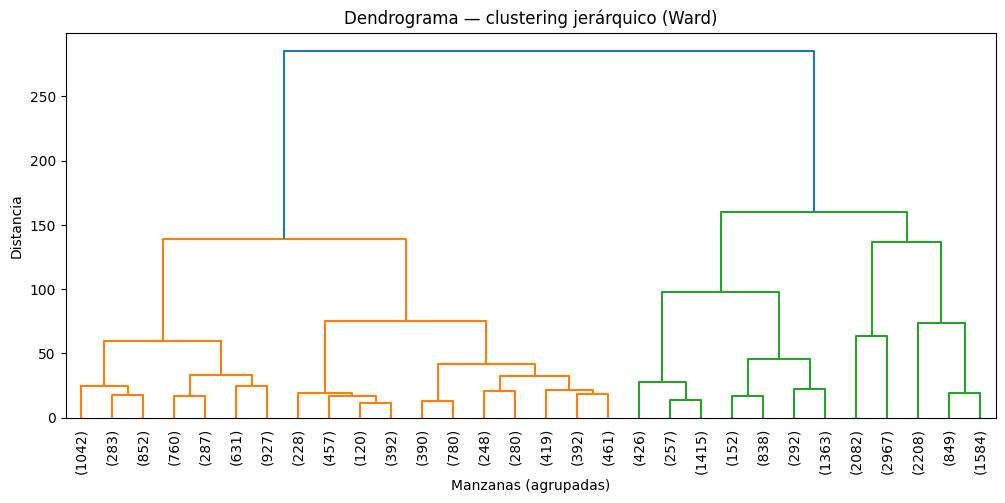

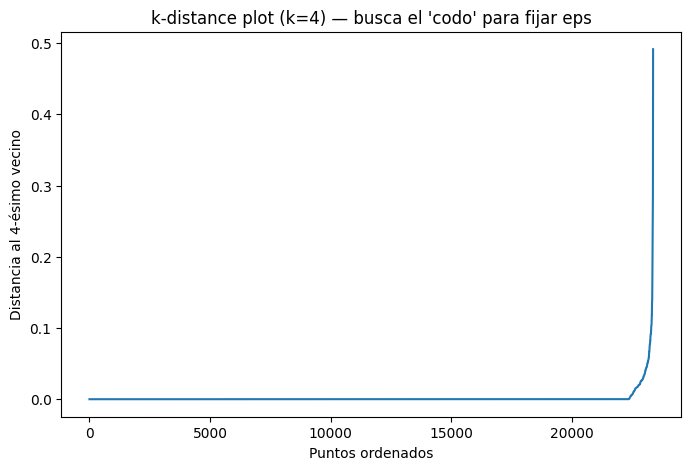

In [0]:
# Clustering jerárquico (aglomerativo) y DBSCAN -- vía scikit-learn sobre pandas
import numpy as np
import pandas as pd
from sklearn.cluster import AgglomerativeClustering, DBSCAN
from sklearn.neighbors import NearestNeighbors
from scipy.cluster.hierarchy import dendrogram, linkage
import matplotlib.pyplot as plt

pdf = spark.table("gold_manzanas_clustering_scaled").select(
    "cvegeo_mzn", "cve_mun", *feature_cols
).toPandas()

X = pdf[feature_cols].values
# Re-escalar en pandas para asegurar consistencia con sklearn (mismo criterio que StandardScaler de Spark)
from sklearn.preprocessing import StandardScaler as SkScaler
X_scaled = SkScaler().fit_transform(X)

# --- Clustering jerárquico ---
Z = linkage(X_scaled, method="ward")
plt.figure(figsize=(12, 5))
dendrogram(Z, truncate_mode="lastp", p=30, leaf_rotation=90.)
plt.title("Dendrograma — clustering jerárquico (Ward)")
plt.xlabel("Manzanas (agrupadas)")
plt.ylabel("Distancia")
plt.show()

n_clusters_jerarquico = mejor_k  # usa el mismo k que K-Means para comparar resultados directamente
agg = AgglomerativeClustering(n_clusters=n_clusters_jerarquico, linkage="ward")
pdf["cluster_jerarquico"] = agg.fit_predict(X_scaled)

# --- DBSCAN: encontrar eps con k-distance plot antes de fijar el valor ---
k_vecinos = 4  # regla práctica: 2*n_dimensiones (aquí 4 variables -> k=4 a 8, prueba ambos)
neigh = NearestNeighbors(n_neighbors=k_vecinos)
neigh.fit(X_scaled)
distancias, _ = neigh.kneighbors(X_scaled)
k_distancias = np.sort(distancias[:, -1])

plt.figure(figsize=(8, 5))
plt.plot(k_distancias)
plt.title(f"k-distance plot (k={k_vecinos}) — busca el 'codo' para fijar eps")
plt.xlabel("Puntos ordenados")
plt.ylabel(f"Distancia al {k_vecinos}-ésimo vecino")
plt.show()


In [0]:
# Tras inspeccionar visualmente el 'codo' del k-distance plot, fija eps aquí:
eps_dbscan = 0.5  # <-- AJUSTA este valor según el codo que veas en la gráfica anterior
min_samples_dbscan = k_vecinos

dbscan = DBSCAN(eps=eps_dbscan, min_samples=min_samples_dbscan)
pdf["cluster_dbscan"] = dbscan.fit_predict(X_scaled)  # -1 = ruido / outlier

n_clusters_dbscan = len(set(pdf["cluster_dbscan"])) - (1 if -1 in pdf["cluster_dbscan"].values else 0)
n_ruido = (pdf["cluster_dbscan"] == -1).sum()
print(f"DBSCAN: {n_clusters_dbscan} clusters encontrados, {n_ruido} manzanas marcadas como ruido/outlier")

# Guardar resultados de jerárquico y DBSCAN junto con K-Means para comparar los 3 métodos
df_kmeans_pd = spark.table("gold_resultado_kmeans").select("cvegeo_mzn", "cluster_kmeans").toPandas()
pdf_comparacion = pdf.merge(df_kmeans_pd, on="cvegeo_mzn", how="left")

spark.createDataFrame(pdf_comparacion).write.format("delta").mode("overwrite").option("overwriteSchema", "true").saveAsTable("gold_comparacion_clustering")
display(spark.table("gold_comparacion_clustering").limit(20))

DBSCAN: 19 clusters encontrados, 0 manzanas marcadas como ruido/outlier


cvegeo_mzn,cve_mun,densidad_urbana,densidad_urbana_neta,indice_entropia_negocios,personas_mayores_o_iguales_18,cluster_jerarquico,cluster_dbscan,cluster_kmeans
0901700010225002,017,13179.5683041246,17321.066366254192,0.0,347576,3,18,1
0901700010210016,017,13179.5683041246,17321.066366254192,0.579380164285695,347576,2,18,3
0901700010210014,017,13179.5683041246,17321.066366254192,0.9463946303571862,347576,2,18,3
0901700010210013,017,13179.5683041246,17321.066366254192,0.6126016192893443,347576,2,18,3
0901700010210003,017,13179.5683041246,17321.066366254192,0.0,347576,3,18,1
0901700010210002,017,13179.5683041246,17321.066366254192,0.579380164285695,347576,2,18,3
0901700010210001,017,13179.5683041246,17321.066366254192,0.0,347576,3,18,1
0901700010206017,017,13179.5683041246,17321.066366254192,0.0,347576,3,18,1
0901700010206003,017,13179.5683041246,17321.066366254192,0.0,347576,3,18,1
0901700010193021,017,13179.5683041246,17321.066366254192,0.0,347576,3,18,1


## 10. Validación y comparación entre algoritmos

Para el artículo, vale la pena reportar al menos:
- **Silhouette score** para K-Means y jerárquico (ya con el mismo k, son directamente comparables).
- **% de manzanas como ruido** en DBSCAN (si es muy alto, `eps`/`min_samples` necesitan ajuste — generalmente
  síntoma de que las 4 variables a esa escala producen densidades muy desiguales entre municipios).
- **Tabla cruzada** (`crosstab`) entre `cluster_kmeans` y `cluster_jerarquico` para ver si ambos métodos coinciden
  en la segmentación — coincidencia alta refuerza la robustez de los clusters encontrados para tu publicación.

In [0]:
# Validación rápida
from sklearn.metrics import silhouette_score

sil_kmeans = silhouette_score(X_scaled, pdf_comparacion["cluster_kmeans"])
sil_jerarquico = silhouette_score(X_scaled, pdf_comparacion["cluster_jerarquico"])
print(f"Silhouette K-Means:    {sil_kmeans:.4f}")
print(f"Silhouette Jerárquico: {sil_jerarquico:.4f}")

if n_clusters_dbscan > 1:
    mask = pdf_comparacion["cluster_dbscan"] != -1
    sil_dbscan = silhouette_score(X_scaled[mask], pdf_comparacion.loc[mask, "cluster_dbscan"])
    print(f"Silhouette DBSCAN (sin ruido): {sil_dbscan:.4f}")

print()
print("Tabla cruzada K-Means vs Jerárquico:")
print(pd.crosstab(pdf_comparacion["cluster_kmeans"], pdf_comparacion["cluster_jerarquico"]))

Silhouette K-Means:    0.6261
Silhouette Jerárquico: 0.5572
Silhouette DBSCAN (sin ruido): 0.4303

Tabla cruzada K-Means vs Jerárquico:
cluster_jerarquico     0     1     2     3     4     5     6     7
cluster_kmeans                                                    
0                      0  3224     1     0     0     0    11     0
1                      0  1558    55  2433     0     0     0     0
2                   2967     0     0     0    13     0     0     0
3                      0     0  1379     0     0  2011     0     0
4                   2082     0     0     0    21     0     0     0
5                      0     0     0     0  2611     0     0     0
6                      0     0     0     0     0    87     0  2208
7                      0     0  1535     0     0     0  1186     0


Manzanas con coordenadas para graficar: 23382 de 23382


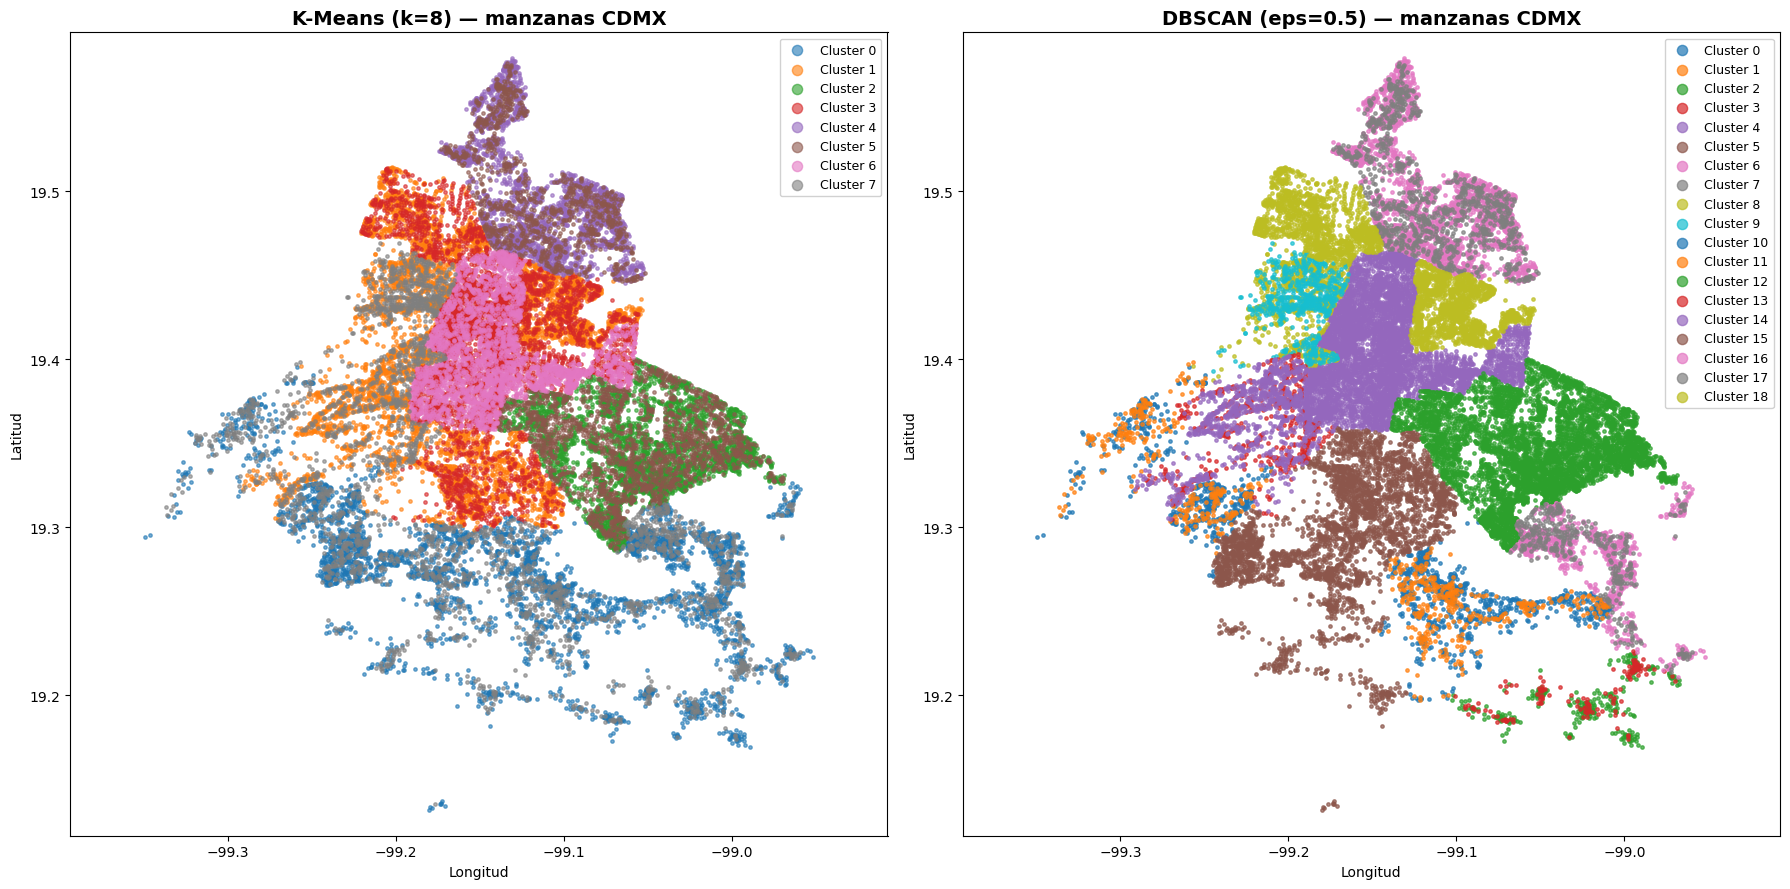

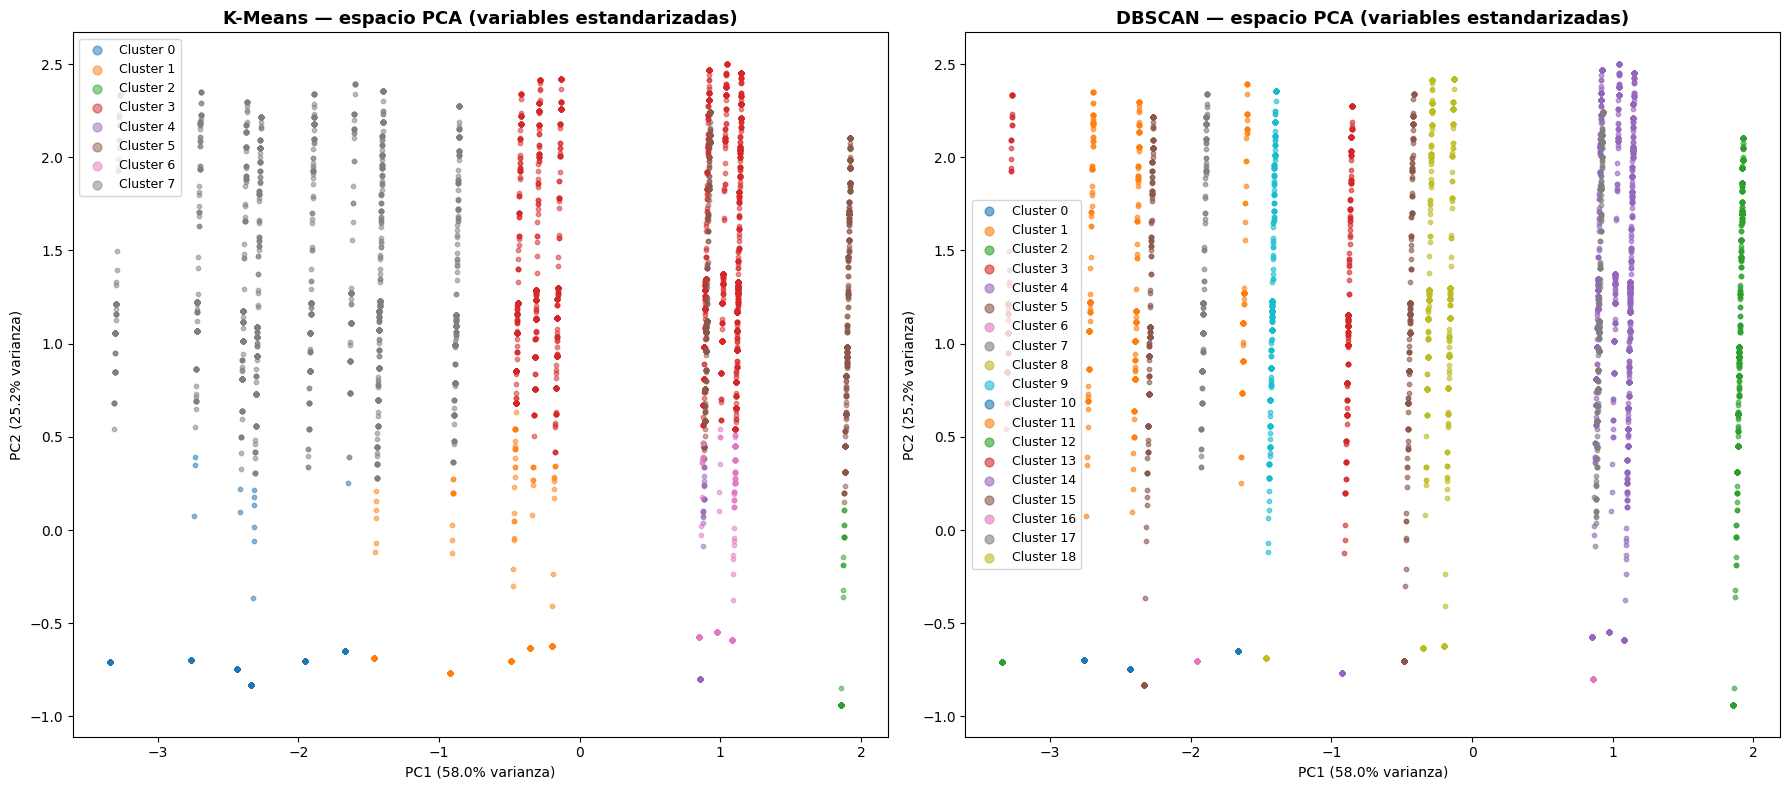

Perfil promedio de variables por cluster (K-Means, escala original):


densidad_urbana,densidad_urbana_neta,indice_entropia_negocios,personas_mayores_o_iguales_18,n_manzanas
3185.95,9398.4,0.0,347616.76,3236
10901.59,14902.51,0.0,434009.76,4046
16311.36,21692.22,0.0,1383459.0,2980
15092.08,20432.44,0.64,398514.26,3390
13428.4,20703.01,0.0,911482.0,2103
15241.43,21325.1,0.65,1208297.87,2611
16891.56,23242.47,0.01,385283.18,2295
5176.65,10419.56,0.65,384277.7,2721


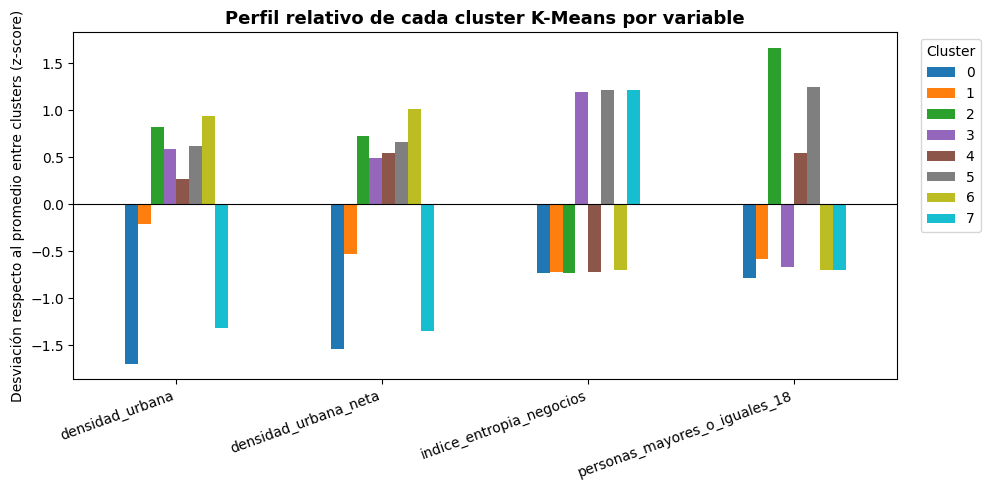

In [0]:
# %pip install matplotlib seaborn --quiet   # descomenta si no los tienes instalados

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

# 1) Traer centroides (lat/lon) y unirlos a la tabla de comparación de clusters
pdf_centroides = spark.table("silver_manzanas").select("cvegeo_mzn", "centroid_lat", "centroid_lon").toPandas()
pdf_viz = pdf_comparacion.merge(pdf_centroides, on="cvegeo_mzn", how="left")

print("Manzanas con coordenadas para graficar:", pdf_viz["centroid_lat"].notna().sum(), "de", len(pdf_viz))

# 2) MAPA GEOGRÁFICO — K-Means vs DBSCAN, lado a lado
fig, axes = plt.subplots(1, 2, figsize=(18, 9))

# --- K-Means ---
ax = axes[0]
clusters_km = sorted(pdf_viz["cluster_kmeans"].dropna().unique())
palette_km = sns.color_palette("tab10", n_colors=len(clusters_km))

for color, cl in zip(palette_km, clusters_km):
    subset = pdf_viz[pdf_viz["cluster_kmeans"] == cl]
    ax.scatter(subset["centroid_lon"], subset["centroid_lat"],
               s=6, color=color, alpha=0.6, label=f"Cluster {cl}")

ax.set_title(f"K-Means (k={mejor_k}) — manzanas CDMX", fontsize=14, fontweight="bold")
ax.set_xlabel("Longitud")
ax.set_ylabel("Latitud")
ax.legend(markerscale=3, fontsize=9, loc="best", framealpha=0.9)
ax.set_aspect("equal", adjustable="datalim")

# --- DBSCAN ---
ax = axes[1]
clusters_db = sorted(pdf_viz["cluster_dbscan"].dropna().unique())
clusters_db_validos = [c for c in clusters_db if c != -1]
palette_db = sns.color_palette("tab10", n_colors=max(len(clusters_db_validos), 1))

ruido = pdf_viz[pdf_viz["cluster_dbscan"] == -1]
if len(ruido) > 0:
    ax.scatter(ruido["centroid_lon"], ruido["centroid_lat"],
               s=6, color="lightgray", alpha=0.4, label=f"Ruido (-1): {len(ruido)} manzanas")

for color, cl in zip(palette_db, clusters_db_validos):
    subset = pdf_viz[pdf_viz["cluster_dbscan"] == cl]
    ax.scatter(subset["centroid_lon"], subset["centroid_lat"],
               s=6, color=color, alpha=0.7, label=f"Cluster {cl}")

ax.set_title(f"DBSCAN (eps={eps_dbscan}) — manzanas CDMX", fontsize=14, fontweight="bold")
ax.set_xlabel("Longitud")
ax.set_ylabel("Latitud")
ax.legend(markerscale=3, fontsize=9, loc="best", framealpha=0.9)
ax.set_aspect("equal", adjustable="datalim")

plt.tight_layout()
plt.show()

# 3) ESPACIO DE FEATURES (PCA 2D) — K-Means vs DBSCAN
from sklearn.decomposition import PCA

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)  # X_scaled ya viene de la celda de clustering
var_explicada = pca.explained_variance_ratio_

fig, axes = plt.subplots(1, 2, figsize=(18, 8))

ax = axes[0]
for color, cl in zip(palette_km, clusters_km):
    mask = pdf_comparacion["cluster_kmeans"] == cl
    ax.scatter(X_pca[mask, 0], X_pca[mask, 1], s=10, color=color, alpha=0.5, label=f"Cluster {cl}")
ax.set_title("K-Means — espacio PCA (variables estandarizadas)", fontsize=13, fontweight="bold")
ax.set_xlabel(f"PC1 ({var_explicada[0]*100:.1f}% varianza)")
ax.set_ylabel(f"PC2 ({var_explicada[1]*100:.1f}% varianza)")
ax.legend(markerscale=2, fontsize=9)

ax = axes[1]
mask_ruido = pdf_comparacion["cluster_dbscan"] == -1
if mask_ruido.sum() > 0:
    ax.scatter(X_pca[mask_ruido, 0], X_pca[mask_ruido, 1], s=10, color="lightgray", alpha=0.3, label="Ruido (-1)")
for color, cl in zip(palette_db, clusters_db_validos):
    mask = pdf_comparacion["cluster_dbscan"] == cl
    ax.scatter(X_pca[mask, 0], X_pca[mask, 1], s=10, color=color, alpha=0.6, label=f"Cluster {cl}")
ax.set_title("DBSCAN — espacio PCA (variables estandarizadas)", fontsize=13, fontweight="bold")
ax.set_xlabel(f"PC1 ({var_explicada[0]*100:.1f}% varianza)")
ax.set_ylabel(f"PC2 ({var_explicada[1]*100:.1f}% varianza)")
ax.legend(markerscale=2, fontsize=9)

plt.tight_layout()
plt.show()

# 4) PERFIL DE VARIABLES POR CLUSTER — qué caracteriza a cada grupo (K-Means)
perfil_kmeans = pdf_comparacion.groupby("cluster_kmeans")[feature_cols].mean()
perfil_kmeans["n_manzanas"] = pdf_comparacion.groupby("cluster_kmeans").size()
print("Perfil promedio de variables por cluster (K-Means, escala original):")
display(perfil_kmeans.round(2))

fig, ax = plt.subplots(figsize=(10, 5))
perfil_normalizado = (perfil_kmeans[feature_cols] - perfil_kmeans[feature_cols].mean()) / perfil_kmeans[feature_cols].std()
perfil_normalizado.T.plot(kind="bar", ax=ax, colormap="tab10")
ax.set_title("Perfil relativo de cada cluster K-Means por variable", fontsize=13, fontweight="bold")
ax.set_ylabel("Desviación respecto al promedio entre clusters (z-score)")
ax.axhline(0, color="black", linewidth=0.8)
ax.legend(title="Cluster", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()